In [ ]:
import pandas as pd

In [ ]:
data = pd.read_csv('parkinsons_updrs.csv')
data.head()


,subject#,age,sex,test_time,motor_UPDRS,total_UPDRS,Jitter(%),Jitter(Abs),Jitter:RAP,Jitter:PPQ5,...,Shimmer(dB),Shimmer:APQ3,Shimmer:APQ5,Shimmer:APQ11,Shimmer:DDA,NHR,HNR,RPDE,DFA,PPE
0,1,72,0,5.6431,28.199,34.398,0.00662,0.000034,0.00401,0.00317,...,0.230,0.01438,0.01309,0.01662,0.04314,0.014290,21.640,0.41888,0.54842,0.16006
1,1,72,0,12.6660,28.447,34.894,0.00300,0.000017,0.00132,0.00150,...,0.179,0.00994,0.01072,0.01689,0.02982,0.011112,27.183,0.43493,0.56477,0.10810
2,1,72,0,19.6810,28.695,35.389,0.00481,0.000025,0.00205,0.00208,...,0.181,0.00734,0.00844,0.01458,0.02202,0.020220,23.047,0.46222,0.54405,0.21014
3,1,72,0,25.6470,28.905,35.810,0.00528,0.000027,0.00191,0.00264,...,0.327,0.01106,0.01265,0.01963,0.03317,0.027837,24.445,0.48730,0.57794,0.33277
4,1,72,0,33.6420,29.187,36.375,0.00335,0.000020,0.00093,0.00130,...,0.176,0.00679,0.00929,0.01819,0.02036,0.011625,26.126,0.47188,0.56122,0.19361


In [ ]:
from sklearn.datasets import load_iris
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split

In [ ]:
# Import necessary libraries
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score

In [ ]:
# Load dataset
df = pd.read_csv('parkinsons_updrs.csv')

In [ ]:
# Explore the data
print(df.head())
print(df.columns)

   subject#  age  sex  test_time  motor_UPDRS  total_UPDRS  Jitter(%)  \
0         1   72    0     5.6431       28.199       34.398    0.00662   
1         1   72    0    12.6660       28.447       34.894    0.00300   
2         1   72    0    19.6810       28.695       35.389    0.00481   
3         1   72    0    25.6470       28.905       35.810    0.00528   
4         1   72    0    33.6420       29.187       36.375    0.00335   

   Jitter(Abs)  Jitter:RAP  Jitter:PPQ5  ...  Shimmer(dB)  Shimmer:APQ3  \
0     0.000034     0.00401      0.00317  ...        0.230       0.01438   
1     0.000017     0.00132      0.00150  ...        0.179       0.00994   
2     0.000025     0.00205      0.00208  ...        0.181       0.00734   
3     0.000027     0.00191      0.00264  ...        0.327       0.01106   
4     0.000020     0.00093      0.00130  ...        0.176       0.00679   

   Shimmer:APQ5  Shimmer:APQ11  Shimmer:DDA       NHR     HNR     RPDE  \
0       0.01309        0.01662      

In [ ]:
df['mild_park'] = df['total_UPDRS'].apply(lambda x: 1 if x > 32 else 0)
df.mild_park.value_counts().reset_index()

,mild_park,count
0,0,3800
1,1,2075


In [ ]:
df.groupby('mild_park').agg({'total_UPDRS':'max'}).reset_index()

,mild_park,total_UPDRS
0,0,32.000
1,1,54.992


In [ ]:
# Choose target and features
# Let's predict 'total_UPDRS' using all other features except subject
X = df.drop(['total_UPDRS', 'subject#'], axis=1)
y = df['mild_park']

In [ ]:
# Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

In [ ]:
# Fit Random Forest Regressor
# Initialize and train model
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

In [ ]:
# Predict
y_pred = rf.predict(X_test)

In [ ]:
# Evaluate
print("R² score:", r2_score(y_test, y_pred))
print("MSE:", mean_squared_error(y_test, y_pred))

R² score: 1.0
MSE: 0.0


In [ ]:
# Define the model with custom hyperparameters
rf = RandomForestRegressor(
    n_estimators=200,        # Number of trees in the forest
    max_depth=4,            # Maximum depth of each tree
    min_samples_split=100,     # Minimum samples required to split an internal node
    min_samples_leaf=50,      # Minimum samples required to be at a leaf node
    max_features='sqrt',     # Number of features to consider at each split
    random_state=42,         # Reproducibility
    n_jobs=-1                # Use all CPU cores for faster training
)

In [ ]:
# Random forest

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report


In [ ]:
# Step 1: Define features and target
X = df.drop(['total_UPDRS', 'motor_UPDRS', 'mild_park', 'subject#'], axis=1)  # features
y = df['mild_park']                 # target (0 = healthy, 1 = Parkinson’s)


In [ ]:
# Step 2: Split the data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

In [ ]:
# step 3: Define hyperparameters for random forest model
n_estimators = 100
max_depth = None
min_samples_leaf = 1

In [ ]:
# step 5: Initialize the model with hyperparameters
model = RandomForestClassifier(
    n_estimators=n_estimators,
    max_depth=max_depth,
    min_samples_leaf=min_samples_leaf,
    random_state=42)




model.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

In [ ]:


# Step 6: Predict on test set
y_pred = model.predict(X_test)

# Step 7: Predict probabilities (not just 0/1)
y_proba = model.predict_proba(X_train)[:, 1]  # Probabilities for class 1

# Step 8: Calculate AUC
auc_score = roc_auc_score(y_train, y_proba)
print("AUC Score:", auc_score)

# Step 9: Calculate Gini Coefficient
gini_coefficient = 2 * auc_score - 1
print("Gini Coefficient Train :", gini_coefficient)

# Step 10: Evaluate the model
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print("F1 Score:", f1_score(y_test, y_pred))


AUC Score: 0.9829753403972153
Gini Coefficient Test: 0.9659506807944307
AUC Score: 1.0
Gini Coefficient Train : 1.0
Accuracy: 0.9225531914893617
Precision: 0.9593023255813954
Recall: 0.8108108108108109
F1 Score: 0.8788282290279628


In [ ]:
model.feature_importances_

array([0.23472677, 0.02413011, 0.06663046, 0.03337343, 0.05685715,
       0.0312859 , 0.03516095, 0.03200108, 0.030245  , 0.03117333,
       0.0360226 , 0.03414114, 0.03461255, 0.03454003, 0.04088904,
       0.04787465, 0.04859162, 0.09847724, 0.04926694])

In [ ]:
X_train.columns

Index(['age', 'sex', 'test_time', 'Jitter(%)', 'Jitter(Abs)', 'Jitter:RAP',
       'Jitter:PPQ5', 'Jitter:DDP', 'Shimmer', 'Shimmer(dB)', 'Shimmer:APQ3',
       'Shimmer:APQ5', 'Shimmer:APQ11', 'Shimmer:DDA', 'NHR', 'HNR', 'RPDE',
       'DFA', 'PPE'],
      dtype='object')

In [ ]:
# Niave Bayes Algorithm

from sklearn.naive_bayes import GaussianNB
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix, ConfusionMatrixDisplay, classification_report
)
import matplotlib.pyplot as plt

In [ ]:
# Step 1: Define features and target
X = df.drop(['total_UPDRS', 'motor_UPDRS', 'mild_park', 'subject#'], axis=1)  # features
y = df['mild_park']                 # target (0 = healthy, 1 = Parkinson’s)

# Step 2: Split the data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

# Step 4: Initialize and train Gaussian Naive Bayes model
model = GaussianNB()
model.fit(X_train, y_train)

# Step 5: Make predictions
y_pred = model.predict(X_test)
y_proba = model.predict_proba(X_test)[:, 1]  # Probability of class 1

# Step 6: Evaluate model performance
print("Accuracy :", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall   :", recall_score(y_test, y_pred))
print("F1 Score :", f1_score(y_test, y_pred))

# AUC and Gini
auc = roc_auc_score(y_test, y_proba)
gini = 2 * auc - 1
print("AUC Score        :", auc)
print("Gini Coefficient :", gini)

# Step 7: Classification Report
print("\nClassification Report:\n", classification_report(y_test, y_pred))

Accuracy : 0.4127659574468085
Precision: 0.35835835835835833
Recall   : 0.8796068796068796
F1 Score : 0.5092460881934566
AUC Score        : 0.5736204954954955
Gini Coefficient : 0.14724099099099108

Classification Report:
               precision    recall  f1-score   support

           0       0.72      0.17      0.27       768
           1       0.36      0.88      0.51       407

    accuracy                           0.41      1175
   macro avg       0.54      0.52      0.39      1175
weighted avg       0.60      0.41      0.35      1175



In [ ]:
# Artificial Neural Network

from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix, ConfusionMatrixDisplay, classification_report
)
import matplotlib.pyplot as plt
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.optimizers import Adam

# Standardize features
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Step 3: Define the ANN model
model = Sequential([
    Dense(32, activation='relu', input_shape=(X_train.shape[1],)),
    Dense(16, activation='relu'),
    Dense(1, activation='sigmoid')  # Sigmoid for binary classification
])

# Step 4: Compile the model
model.compile(optimizer=Adam(learning_rate=0.001),
              loss='binary_crossentropy',
              metrics=['accuracy'])

# Step 5: Train the model
history = model.fit(X_train, y_train, epochs=100, batch_size=16, verbose=0)

# Step 6: Predictions and Evaluation
y_pred_prob = model.predict(X_test).ravel()
y_pred = (y_pred_prob >= 0.5).astype(int)

# Performance metrics
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
auc = roc_auc_score(y_test, y_pred_prob)
gini = 2 * auc - 1

print("Accuracy :", accuracy)
print("Precision:", precision)
print("Recall   :", recall)
print("F1 Score :", f1)
print("AUC Score        :", auc)
print("Gini Coefficient :", gini)
print("\nClassification Report:\n", classification_report(y_test, y_pred))


/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


37/37 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step
Accuracy : 0.8953191489361703
Precision: 0.8622448979591837
Recall   : 0.8304668304668305
F1 Score : 0.8460575719649562
AUC Score        : 0.9546254350941852
Gini Coefficient : 0.9092508701883704

Classification Report:
               precision    recall  f1-score   support

           0       0.91      0.93      0.92       768
           1       0.86      0.83      0.85       407

    accuracy                           0.90      1175
   macro avg       0.89      0.88      0.88      1175
weighted avg       0.89      0.90      0.89      1175



In [ ]:
# XGBoost

In [ ]:
import xgboost as xgb
# Step 1: Define features and target
X = df.drop(['total_UPDRS', 'motor_UPDRS', 'mild_park', 'subject#'], axis=1)  # features
y = df['mild_park']                 # target (0 = healthy, 1 = Parkinson’s)

# Step 2: Split the data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)


# Step 3: Initialize and train XGBoost model
model = xgb.XGBClassifier(
    objective='binary:logistic',
    eval_metric='logloss',
    use_label_encoder=False,
    random_state=42
)
model.fit(X_train, y_train)

# Step 4: Predictions and Evaluation
y_pred = model.predict(X_test)
y_proba = model.predict_proba(X_test)[:, 1]

# Step 5: Performance Metrics
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
auc = roc_auc_score(y_test, y_proba)
gini = 2 * auc - 1

print("Accuracy :", accuracy)
print("Precision:", precision)
print("Recall   :", recall)
print("F1 Score :", f1)
print("AUC Score        :", auc)
print("Gini Coefficient :", gini)
print("\nClassification Report:\n", classification_report(y_test, y_pred))


/usr/local/lib/python3.11/dist-packages/xgboost/core.py:158: UserWarning: [06:03:46] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)


Accuracy : 0.9923404255319149
Precision: 0.9950248756218906
Recall   : 0.9828009828009828
F1 Score : 0.9888751545117429
AUC Score        : 0.9996192925880426
Gini Coefficient : 0.9992385851760852

Classification Report:
               precision    recall  f1-score   support

           0       0.99      1.00      0.99       768
           1       1.00      0.98      0.99       407

    accuracy                           0.99      1175
   macro avg       0.99      0.99      0.99      1175
weighted avg       0.99      0.99      0.99      1175



In [ ]:
import lightgbm as lgb
# Step 1: Define features and target
X = df.drop(['total_UPDRS', 'motor_UPDRS', 'mild_park', 'subject#'], axis=1)  # features
y = df['mild_park']                 # target (0 = healthy, 1 = Parkinson’s)

# Step 2: Split the data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

# Optional: Standardize features (LightGBM usually doesn't need this)
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Step 4: Initialize and train LightGBM model
model = lgb.LGBMClassifier(random_state=42)

model.fit(X_train, y_train)

# Step 5: Make predictions
y_pred = model.predict(X_test)
y_proba = model.predict_proba(X_test)[:, 1]

# Step 6: Evaluate model performance
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
auc = roc_auc_score(y_test, y_proba)
gini = 2 * auc - 1

print("Accuracy :", accuracy)
print("Precision:", precision)
print("Recall   :", recall)
print("F1 Score :", f1)
print("AUC Score        :", auc)
print("Gini Coefficient :", gini)
print("\nClassification Report:\n", classification_report(y_test, y_pred))

/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


[LightGBM] [Info] Number of positive: 1668, number of negative: 3032
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.002170 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 4362
[LightGBM] [Info] Number of data points in the train set: 4700, number of used features: 19
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.354894 -> initscore=-0.597597
[LightGBM] [Info] Start training from score -0.597597
Accuracy : 0.9940425531914894
Precision: 0.9975124378109452
Recall   : 0.9852579852579852
F1 Score : 0.9913473423980222
AUC Score        : 0.999798449017199
Gini Coefficient : 0.9995968980343981

Classification Report:
               precision    recall  f1-score   support

           0       0.99      1.00      1.00       768
           1       1.00      0.99      0.99       407

    accuracy                           0.99      1175
   macr

/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


In [ ]:
# KNN (K-nearest neighbour)

Classification Report:
              precision    recall  f1-score   support

           0       0.83      0.83      0.83       401
           1       0.80      0.83      0.82       387
           2       0.80      0.78      0.79       387

    accuracy                           0.81      1175
   macro avg       0.81      0.81      0.81      1175
weighted avg       0.81      0.81      0.81      1175



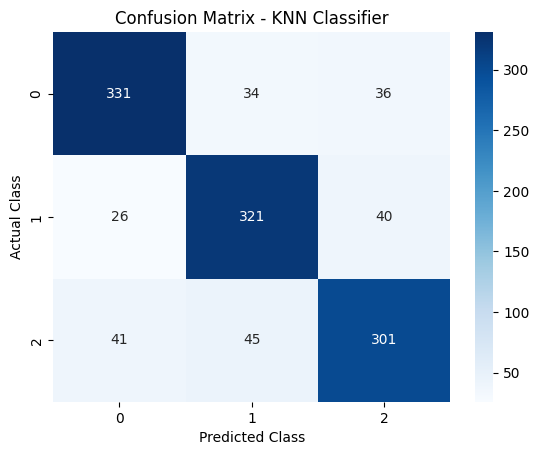

In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, KBinsDiscretizer
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# Step 1: Load dataset
df = pd.read_csv("parkinsons_updrs.csv")

# Step 2: Prepare features and target
X = df.drop(columns=["subject#", "motor_UPDRS", "total_UPDRS"])
y_continuous = df["total_UPDRS"]

# Step 3: Discretize target into 3 classes (Low, Medium, High)
discretizer = KBinsDiscretizer(n_bins=3, encode='ordinal', strategy='quantile')
y_class = discretizer.fit_transform(y_continuous.values.reshape(-1, 1)).ravel().astype(int)

# Step 4: Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y_class, test_size=0.2, random_state=42)

# Step 5: Feature scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Step 6: Train KNN Classifier
knn_clf = KNeighborsClassifier(n_neighbors=5)
knn_clf.fit(X_train_scaled, y_train)

# Step 7: Predict and evaluate
y_pred = knn_clf.predict(X_test_scaled)

# Classification metrics
print("Classification Report:")
print(classification_report(y_test, y_pred))

# Confusion matrix
conf_matrix = confusion_matrix(y_test, y_pred)
sns.heatmap(conf_matrix, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predicted Class")
plt.ylabel("Actual Class")
plt.title("Confusion Matrix - KNN Classifier")
plt.show()


In [ ]:
# Step 7: Evaluate model performance
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score # Import necessary metrics

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, average='weighted') # Handle multiclass precision
recall = recall_score(y_test, y_pred, average='weighted') # Handle multiclass recall
f1 = f1_score(y_test, y_pred, average='weighted') # Handle multiclass F1-score
# auc = roc_auc_score(y_test, y_proba) # This line may cause error as y_proba may not be defined for KNN
# gini = 2 * auc - 1 # This line depends on auc, so may cause error as well


print("Accuracy :", accuracy)
print("Precision:", precision)
print("Recall   :", recall)
print("F1 Score :", f1)
# print("AUC Score        :", auc) # Commenting out due to potential error
# print("Gini Coefficient :", gini) # Commenting out due to potential error
print("\nClassification Report:\n", classification_report(y_test, y_pred))

Accuracy : 0.811063829787234
Precision: 0.8111034551106455
Recall   : 0.811063829787234
F1 Score : 0.8109618551906713

Classification Report:
               precision    recall  f1-score   support

           0       0.83      0.83      0.83       401
           1       0.80      0.83      0.82       387
           2       0.80      0.78      0.79       387

    accuracy                           0.81      1175
   macro avg       0.81      0.81      0.81      1175
weighted avg       0.81      0.81      0.81      1175



In [ ]:
import numpy as np

In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, KBinsDiscretizer
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# ... (Your existing code for data loading, preprocessing, and model training) ...

# Step 7: Predict and evaluate
y_pred = knn_clf.predict(X_test_scaled)

# ... (Your existing code for classification report) ...

# Confusion matrix
conf_matrix = confusion_matrix(y_test, y_pred)

# Get TP, TN, FP, FN for a binary classification problem (assuming class 1 is positive)
# If you have more than 2 classes, you'll need to adapt this logic
# For multiclass use this
FP = conf_matrix.sum(axis=0) - np.diag(conf_matrix)
FN = conf_matrix.sum(axis=1) - np.diag(conf_matrix)
TP = np.diag(conf_matrix)
TN = conf_matrix.sum() - (FP + FN + TP)

# Print the values
print("True Positives (TP):", TP)
print("True Negatives (TN):", TN)
print("False Positives (FP):", FP)
print("False Negatives (FN):", FN)

# Alternatively, for binary classification, you can access specific elements:
# TP = conf_matrix[1, 1]
# TN = conf_matrix[0, 0]
# FP = conf_matrix[0, 1]
# FN = conf_matrix[1, 0]

# ... (Your existing code to display the confusion matrix heatmap) ...

True Positives (TP): [331 321 301]
True Negatives (TN): [707 709 712]
False Positives (FP): [67 79 76]
False Negatives (FN): [70 66 86]


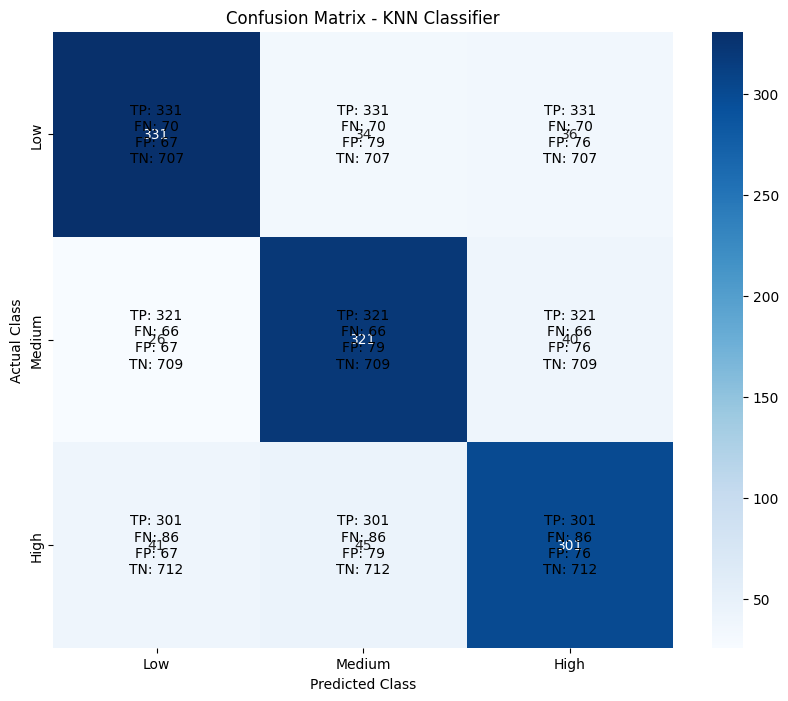

In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, KBinsDiscretizer
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# ... (Your existing code for data loading, preprocessing, and model training) ...

# Step 7: Predict and evaluate
y_pred = knn_clf.predict(X_test_scaled)

# ... (Your existing code for classification report) ...

# Confusion matrix with labels and better visualization
class_names = ['Low', 'Medium', 'High']  # Replace with your actual class names if different
conf_matrix = confusion_matrix(y_test, y_pred)

# Calculate TP, TN, FP, FN for each class
FP = conf_matrix.sum(axis=0) - np.diag(conf_matrix)
FN = conf_matrix.sum(axis=1) - np.diag(conf_matrix)
TP = np.diag(conf_matrix)
TN = conf_matrix.sum() - (FP + FN + TP)

# Create a heatmap for the confusion matrix with TP, TN, FP, FN labels
plt.figure(figsize=(10, 8))  # Adjust figure size if needed
sns.heatmap(conf_matrix, annot=True, fmt="d", cmap="Blues",
            xticklabels=class_names, yticklabels=class_names)
plt.xlabel("Predicted Class")
plt.ylabel("Actual Class")
plt.title("Confusion Matrix - KNN Classifier")

# Add TP, TN, FP, FN labels to the plot
for i in range(len(class_names)):
    for j in range(len(class_names)):
        text = f"TP: {TP[i]}\nFN: {FN[i]}\nFP: {FP[j]}\nTN: {TN[i]}"
        plt.text(j + 0.5, i + 0.5, text, ha='center', va='center', color='black', fontsize=10)

plt.show()